# CS5489 - Machine Learning
# Lecture 5b - Neural Networks
### Dept. of Computer Science, City University of Hong Kong

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats

rbow = plt.get_cmap('rainbow')

# Outline
- History
- Perceptron
- Multi-class logistic regression
- **Multi-layer perceptron (MLP)**

# Extracting features
- The multi-class logistic regression model assumes the inputs are feature vectors.
  - $\mathbf{g} = \mathbf{W}^T\mathbf{x}$
  - $\mathbf{f} = \mathbf{s}(\mathbf{g})$

<center><img src="imgs/mclr.png" width=300></center>

- What if we also want to learn the feature vectors?
  - Replace $\mathbf{x}$ with a feature extractor.
  - For simplicity, we can reuse the same "unit" as the classifier to compute the "features".

- Replace $\mathbf{x}$ with feature extractor $\mathbf{z}=\sigma(\mathbf{A}^T\mathbf{x})$
  - $\mathbf{z}$ is the extracted feature vector (also called *hidden* nodes)
    - $z_i = \sigma(\mathbf{a}_i^T \mathbf{x})$ is a  hidden node.
  - $\sigma()$ is the sigmoid function (also called *activation* function.)
  - $\mathbf{A}$ are the parameters of the feature extractor.

- New model 
  - $\mathbf{z} = \sigma(\mathbf{A}^T\mathbf{x})$
  - $\mathbf{g} = \mathbf{W}^T\mathbf{z}$
  - $\mathbf{f} = \mathbf{s}(\mathbf{g})$
<center><img src="imgs/nn.png" width=450></center>

- **Interpretation**
  - Each hidden node $z_i$ is a "classifier" looking for pattern based on $\mathbf{a}_i$.
  - The output is looking for patterns in the vector $\mathbf{x}$
  - the effect is a non-linear classifier in the input space of $\mathbf{x}$.
<center><img src="imgs/features.png" width=800></center>
  - we can apply this recursively to create features of features ...

# Multi-layer Perceptron
- Add hidden layers between the inputs and outputs
  - each hidden node is a Perceptron (with its own set of weights)
    - its inputs are the outputs from previous layer
    - extracts a feature pattern from the previous layer
  - can model more complex functions

<center><table border=0><tr><td><img src="imgs/neural_net.jpeg" width=350></td><td><img src="imgs/neural_net2.jpeg" width=350></tr></table></center>

- Formally, for one layer: 
  - $\mathbf{h} = f(\mathbf{W}^T \mathbf{x})$
    - Weight matrix $\mathbf{W}$ - one column for each node
    - Input $\mathbf{x}$ - from previous layer
    - Output $\mathbf{h}$ - to next layer
    - $f(a)$ is the activation function - applied to each dimension to get output
- Also called _fully-connected layers_ or _dense layers_

# Activation functions
- There are different types of activation functions:
  - _Sigmoid_ - output [0,1]
  - _Tanh_ - output [-1,1]
  - _Rectifier Linear Unit (ReLU)_ - output [0,$\infty$]


In [2]:
x=linspace(-5,5,200)
fs = {'Sigmoid': lambda x: 1/(1+exp(-x)),
      'Tanh':    lambda x: tanh(x),
      'ReLU':    lambda x: maximum(0,x),
     }

actfig = plt.figure()
for name,f in fs.items():
    plt.plot(x, f(x), label=name)
plt.legend(loc="lower right")
plt.axis([-5,5,-2,2])
plt.grid(True)
plt.close()


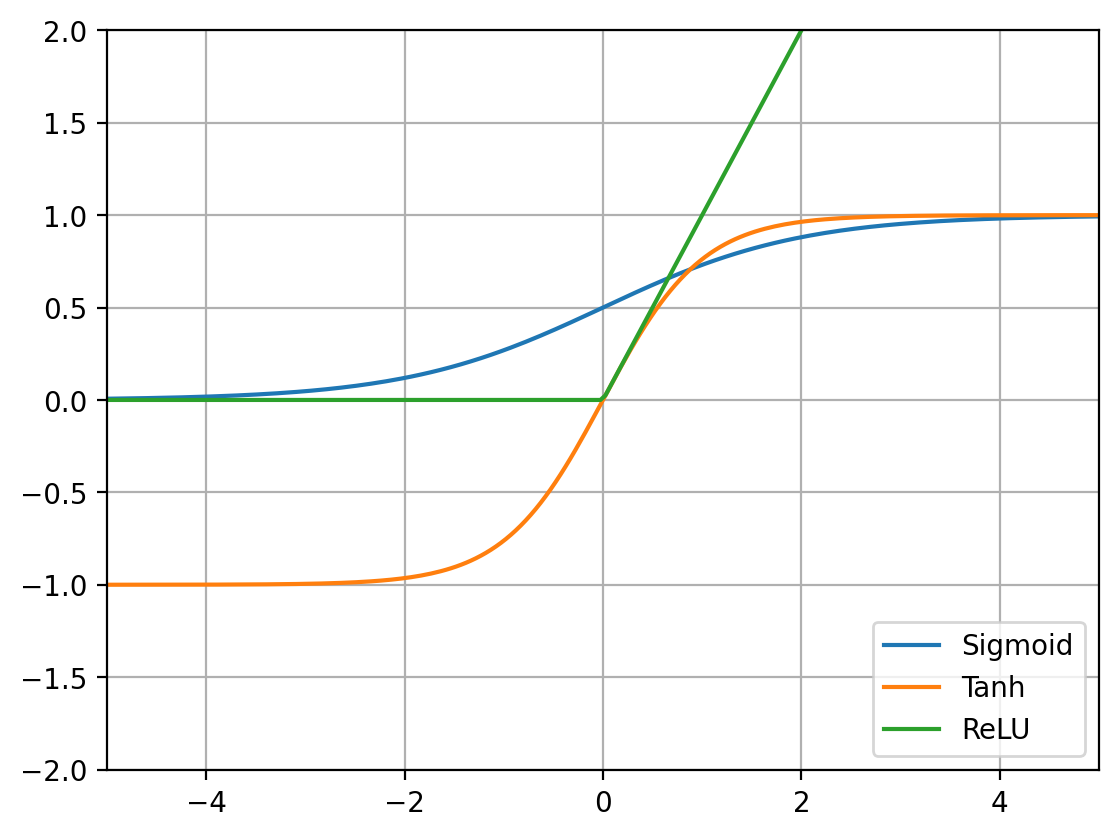

In [3]:
actfig

- Activation functions specifically for output nodes:
  - _Linear_ - output for regression
  - _Softmax_ - output for classification (same as multi-class logistic regression)
  
- Each layer can use a different activation function.

# Which activation function is best?
- In the early days, only the Sigmoid and Tanh activation functions were used.
  - these were notoriously hard to train with.
    - gradient decays to zero on both ends
- Recently, ReLU has become very popular.
  - easier to train with - gradient is either 0 or 1.
  - faster - don't need to calculate exponential
  - sparse representation - most nodes will output zero.
  

# Training an MLP
- Assume a general case:
  - linear transform: $\mathbf{g}_1 = \mathbf{A}^T\mathbf{x}$
  - activation: $\mathbf{z} = h_1(\mathbf{g}_1)$
  - linear transform: $\mathbf{g}_2 = \mathbf{W}^T\mathbf{z}$
  - activation: $\mathbf{f} = h_2(\mathbf{g}_2)$
  - loss function: $L(\mathbf{y}, \mathbf{f})$

<center><img src="imgs/nn2.png" width=450></center>

- In our example, $h_1$ is a  sigmoid, $h_2$ is a softmax.

- Similar to multi-class logistic regression
  - minimize the loss
    - $(\mathbf{A}^*,\mathbf{W}^*) = \mathop{\mathrm{argmin}}_{\mathbf{A}, \mathbf{W}} L(\mathbf{y}, \mathbf{f}(\mathbf{x}))$
  - use gradient descent as before
    - need to compute $\frac{dL}{d\mathbf{A}}$  and $\frac{dL}{d\mathbf{W}}$
    - we have done most of the work already...

- Computation graph
<center><img src="imgs/nn3.png" width=450></center>

- Chain rule:
  - 1) $\color{red}{\frac{dL}{d\mathbf{f}}}$
  - 2) $\color{blue}{\frac{dL}{d\mathbf{g}_2}} = \frac{d\mathbf{f}^T}{d\mathbf{g}_2} \color{red}{\frac{dL}{d\mathbf{f}}}$ $\Rightarrow$  3)$\color{magenta}{\frac{dL}{d \mathbf{w}_j}} = \frac{d\mathbf{g}_2^T}{d\mathbf{w}_j} \color{blue}{\frac{dL}{d\mathbf{g}_2}}$
  - 4) $\color{green}{\frac{dL}{d\mathbf{z}}} = \frac{d\mathbf{g}_2^T}{d\mathbf{z}} \color{blue}{\frac{dL}{d\mathbf{g}_2}}$
  - 5) $\color{purple}{\frac{dL}{d\mathbf{g}_1}} = \frac{d\mathbf{z}^T}{d\mathbf{g}_1} \color{green}{\frac{dL}{d\mathbf{z}}}$ $\Rightarrow$  6) $\color{orange}{\frac{dL}{d \mathbf{a}_j}} = \frac{d\mathbf{g}_1^T}{d\mathbf{a}_j} \color{purple}{\frac{dL}{d\mathbf{g}_1}}$

- Recursively use the gradient of descendant layers
  - propagate gradient backwards 
  - backwards propagation
  - back propagation 
  - backpropagation 
  - backprop
  - BP

# Backpropagation (backward propagation)
- Defines a set of recursive relationships
  1) calculate the output of each node from first to last layer
  2) calculate the gradient of each node from last to first layer
<center><img src="imgs/BP.png" width="100%"></center>

- **NOTE:** the gradients multiply in each layer!
  - if two gradients are small (<1), their product will be even smaller.  This is the "vanishing gradient" problem.



# Backpropagation (general form)
- Given a computation graph
  1) apply input $\mathbf{x}$ and forward propagate to compute all the nodes' values and the loss.
  2) Go backwards from end, at node $\mathbf{h}$:
    - compute gradients from child nodes: $\frac{dL}{d\mathbf{h}} = \sum_{g\in \mathrm{child}(\mathbf{h})} \frac{d\mathbf{g}^T}{d\mathbf{h}} \frac{dL}{d\mathbf{g}}$
    - compute gradient of parameters $\mathbf{w}_h$ of $h$:  $\frac{dL}{d\mathbf{w}_h} =  \frac{d\mathbf{h}^T}{d\mathbf{w}_h} \frac{dL}{d\mathbf{h}}$
- This is the "symbol-to-number" differentiation (e.g., Caffe, Torch).

<center><img src="imgs/compgraph.png" width=400></center>

- We can also make the backprop operations as part of the computation graph.
  - called "symbol-to-symbol" differentiation (e.g., Tensorflow, Theano)
  
<center><img src="imgs/compgraph2.png" width=400></center>

# Stochastic Gradient Descent (SGD)
- The datasets needed to train NN are typically very large
- Use SGD so that only a small portion of the dataset is needed at a time
  - Each small portion is called a _mini-batch_
  - Use a _momentum_ term, which averages the current gradient with those from previous mini-batches.
  - One complete pass through the data is called an _epoch_.

# Monitoring training with SGD
- Separate the training set into training and validation
  - use the training set to run backpropagation
  - test the NN on the validation set for diagnostics
    - check for convergence - adjust learning rate if necessary
    - check for diverging loss - adjust learning rate
    - stopping criteria - stop when no change in the validation error.
    - decay learning rate after each epoch.

# Load NN software
- We will use _pytorch_
  - compatible with scikit-learn
  - pytorch is an easy-to-use and widely-utilized framework

In [4]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [5]:
import sys
print("Python:", sys.version, "Torch", torch.__version__)
from typing import List

Python: 3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:17) [Clang 17.0.6 ] Torch 2.8.0


In [6]:
# initialize random seed
torch.manual_seed(4487)
np.random.seed(4487)
random.seed(4487)

In [7]:
# type three - moons
X0,Y = datasets.make_moons(n_samples=100, noise=0.1, random_state=4487)
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

scaler = preprocessing.MinMaxScaler(feature_range=(-1,1))
X = scaler.fit_transform(X0)

axbox = [-1.2, 1.2, -1.2, 1.2]

In [8]:
def plot_nn(model, axbox, X, Y, mode="prob"):
    # assumes a sigmoid output node
    # grid points
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # make a grid for calculating the posterior, 
    #  then form into a big [N,2] matrix
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = torch.as_tensor(c_[xgrid0.ravel(), xgrid1.ravel()], dtype=torch.float32)

    # print(xgrid0.shape, xgrid1.shape, allpts.shape)

    # calculate the decision function
    if mode == "prob":
        #scoreall = model.predict_proba(allpts) # tf1
        # score = scoreall[:,1].reshape(xgrid0.shape)
        scoreall = model(allpts).softmax(-1)
        score = scoreall[...,1].view(xgrid0.shape).detach().numpy()
        maxscore = 1.0
        minscore = 0.0
        al = 0.3

    plt.imshow(score, origin='lower', extent=axbox, alpha=al, cmap=mycmap, 
               vmin=minscore, vmax=maxscore, aspect='auto')

    plt.contour(xr[0], xr[1], score, levels=[0.5], linestyles='solid', colors='k',
                linewidths=2)
    
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    plt.axis(axbox); plt.grid(True)    

In [9]:
def plot_history(history):    
    plt.plot(history['train_loss'], label="training loss ({:.6f})".format(history['train_loss'][-1]))
    plt.plot(history['val_loss'], label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    plt.grid(True)
    plt.legend(loc="best", fontsize=9)
    plt.axis([0,len(history['train_loss']), 0, 0.7])
    plt.xlabel('iteration')
    plt.ylabel('loss')

In [10]:
# split training and validation
val_num = int(len(X) * 0.1)  # 10% as validation
arr_permute = np.random.permutation(len(X))
X, Y = X[arr_permute], Y[arr_permute]
trainX, trainY = X[:-val_num].astype(np.float32), Y[:-val_num]
valX, valY = X[-val_num:].astype(np.float32), Y[-val_num:]

Let's define a NN module and a training loop with pytorch!

In [11]:
# define the network
class MyModel(nn.Module):
    def __init__(self, input_size: int, output_size: int, hidden_sizes: List[int]):
        super().__init__()
        self.input_size, self.output_size, self.hidden_sizes = input_size, output_size, hidden_sizes
        layers = []
        # for the hidden layers
        prev_size = input_size
        for curr_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, curr_size))  # [bs, hidden_size]
            layers.append(nn.ReLU()) # we use relu activation
            prev_size = curr_size
        # for the output layer
        layers.append(nn.Linear(prev_size, output_size))  # [bs, output_size]
        # layers.append(nn.Softmax(dim=-1))  # we perform softmax at the outside, not here!
        # add to the Module itself
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        t_input = x.view(-1, self.input_size)  # [bs, input_size]
        t_output = self.network(t_input)  # [bs, output_size]
        return t_output

In [12]:
# A summary function to see the parameters of a module
def summary_nn(mod):
    total_numel = 0
    print(mod)
    for name, param in mod.named_parameters():
        total_numel += param.numel()
        print(f"Param: {name}\tShape: {list(param.shape)}\tNumel: {param.numel()}")
    print(f"Total Numel = {total_numel}")

# Overfitting
- Continuous training will sometimes lead to overfitting
  - the training loss decreases, but the validation loss increases
 
# Early stopping

- Training can be stopped when the validation loss is stable for a number of iterations
  - stable means change below a threshold
  - this is to prevent overfitting the training data.
  - we can limit the number of iterations.
- *We are using the loss/accuracy on the (held-out) validation data to estimate the generalization performance of the network*

In [13]:
# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0.0
        self.early_stop = False
        
    def __call__(self, current_accuracy):
        if current_accuracy - self.best_accuracy > self.min_delta:
            self.best_accuracy = current_accuracy
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [14]:
# define the training loop
def train_model(model, criterion, train_loader, valid_loader, total_epoch: int, patience: int):
    # for early stopping
    early_stopping = EarlyStopping(patience=patience)
    # record all the losses and accuracies
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    # all the epochs
    for epoch in range(total_epoch):
        model.train()  # set to training mode
        running_loss = 0.0
        correct = 0
        total = 0
        # loop over the training data
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # 1. Zero the gradients
            outputs = model(inputs)  # 2. Forward pass
            loss = criterion(outputs, labels)  # 3. Calculate the loss
            loss.backward()  # 4. Backward pass
            optimizer.step()  # 5. Optimizer step
            # recordings
            with torch.no_grad():
                running_loss += loss.item()
                predicted = torch.argmax(outputs, -1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        # results for one epoch
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        # Validation
        model.eval()  # set to eval mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = torch.argmax(outputs, -1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        val_loss = val_loss / len(valid_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        # print results
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        if early_stopping(val_acc):
            print("Early stopping triggered")
            break
    return {'train_loss': train_losses, 'train_acc': train_accs, 'val_loss': val_losses, 'val_acc': val_accs}

In [15]:
# get dataset and dataloader
def get_dataloader(t_input, t_output, batch_size=32, shuffle=False):
    t_input, t_output = torch.as_tensor(t_input), torch.as_tensor(t_output)
    dataset = TensorDataset(t_input, t_output)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

- train 1 NN with just one output layer
  - this is the same as logistic regression

In [16]:
model = MyModel(input_size=2, output_size=2, hidden_sizes=[])  # one layer model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(trainX, trainY)  # data loaders
val_loader = get_dataloader(valX, valY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=50)

Epoch 1: Train Loss: 1.0289, Train Acc: 0.2556, Val Loss: 0.8489, Val Acc: 0.2000
Epoch 2: Train Loss: 0.7875, Train Acc: 0.4000, Val Loss: 0.6500, Val Acc: 0.7000
Epoch 3: Train Loss: 0.5473, Train Acc: 0.7889, Val Loss: 0.5168, Val Acc: 0.8000
Epoch 4: Train Loss: 0.3962, Train Acc: 0.8778, Val Loss: 0.4531, Val Acc: 0.8000
Epoch 5: Train Loss: 0.3205, Train Acc: 0.8889, Val Loss: 0.4296, Val Acc: 0.8000
Epoch 6: Train Loss: 0.2851, Train Acc: 0.8889, Val Loss: 0.4257, Val Acc: 0.8000
Epoch 7: Train Loss: 0.2685, Train Acc: 0.8889, Val Loss: 0.4302, Val Acc: 0.8000
Epoch 8: Train Loss: 0.2607, Train Acc: 0.8889, Val Loss: 0.4375, Val Acc: 0.8000
Epoch 9: Train Loss: 0.2569, Train Acc: 0.8889, Val Loss: 0.4448, Val Acc: 0.8000
Epoch 10: Train Loss: 0.2549, Train Acc: 0.8889, Val Loss: 0.4509, Val Acc: 0.8000
Epoch 11: Train Loss: 0.2538, Train Acc: 0.8889, Val Loss: 0.4555, Val Acc: 0.8000
Epoch 12: Train Loss: 0.2530, Train Acc: 0.8889, Val Loss: 0.4586, Val Acc: 0.8000
Epoch 13: Tra

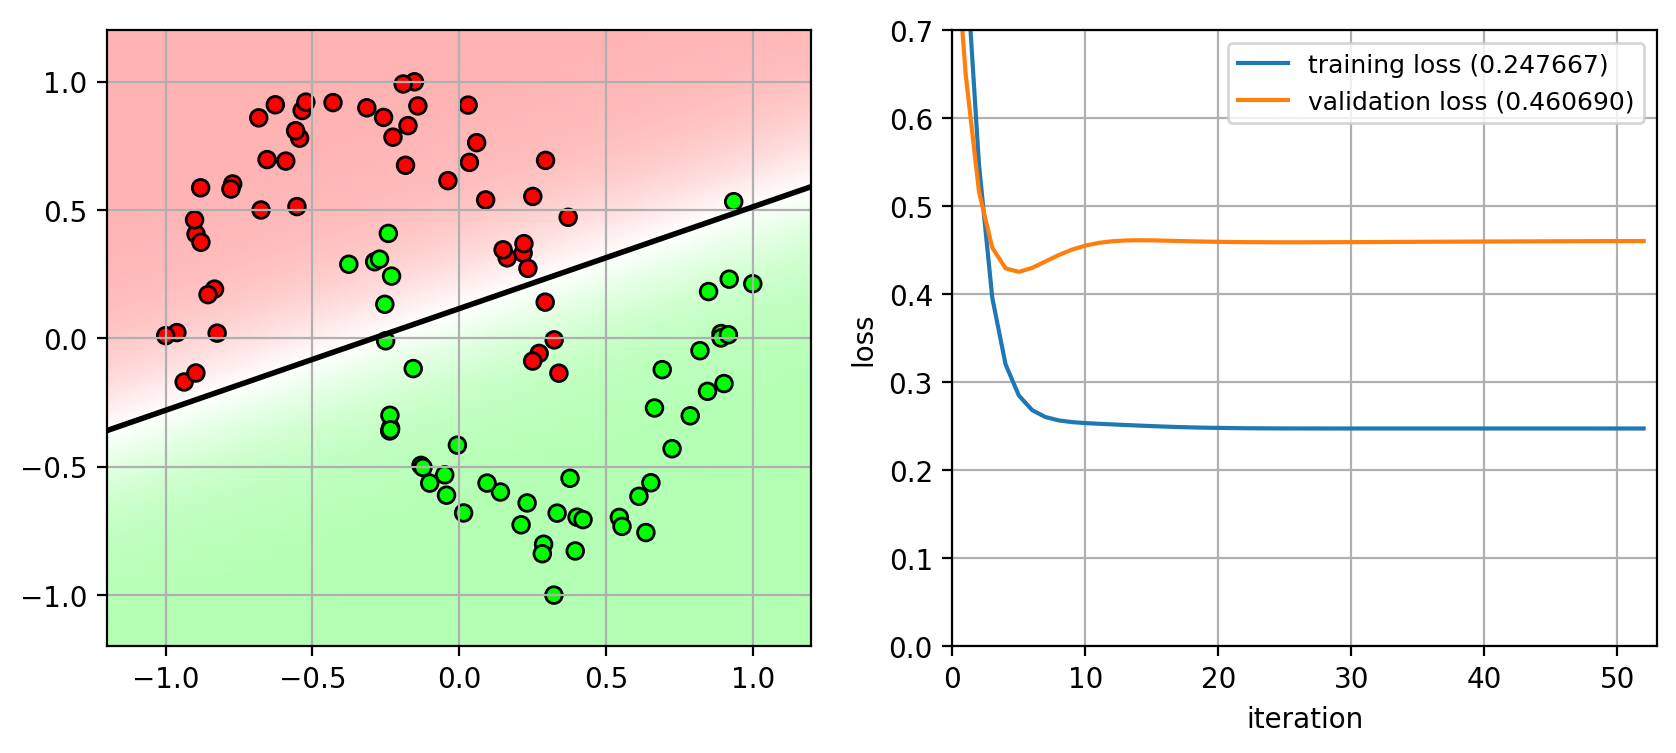

In [17]:
nnfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_nn(model, axbox, X, Y)
plt.subplot(1,2,2)
plot_history(history)
plt.close()

nnfig

- Add one 1 hidden layer with 4 ReLU nodes

In [18]:
model = MyModel(input_size=2, output_size=2, hidden_sizes=[4])  # MLP model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.3, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(trainX, trainY)  # data loaders
val_loader = get_dataloader(valX, valY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=50)

Epoch 1: Train Loss: 0.6305, Train Acc: 0.5889, Val Loss: 0.5638, Val Acc: 0.7000
Epoch 2: Train Loss: 0.4554, Train Acc: 0.8444, Val Loss: 0.4498, Val Acc: 0.7000
Epoch 3: Train Loss: 0.3019, Train Acc: 0.8667, Val Loss: 0.4678, Val Acc: 0.8000
Epoch 4: Train Loss: 0.2763, Train Acc: 0.8889, Val Loss: 0.5332, Val Acc: 0.8000
Epoch 5: Train Loss: 0.2843, Train Acc: 0.9000, Val Loss: 0.5601, Val Acc: 0.8000
Epoch 6: Train Loss: 0.2938, Train Acc: 0.8778, Val Loss: 0.5586, Val Acc: 0.8000
Epoch 7: Train Loss: 0.2960, Train Acc: 0.8667, Val Loss: 0.5324, Val Acc: 0.8000
Epoch 8: Train Loss: 0.2872, Train Acc: 0.8667, Val Loss: 0.4952, Val Acc: 0.8000
Epoch 9: Train Loss: 0.2764, Train Acc: 0.8667, Val Loss: 0.4652, Val Acc: 0.8000
Epoch 10: Train Loss: 0.2709, Train Acc: 0.9000, Val Loss: 0.4473, Val Acc: 0.8000
Epoch 11: Train Loss: 0.2698, Train Acc: 0.9000, Val Loss: 0.4394, Val Acc: 0.8000
Epoch 12: Train Loss: 0.2691, Train Acc: 0.9000, Val Loss: 0.4378, Val Acc: 0.8000
Epoch 13: Tra

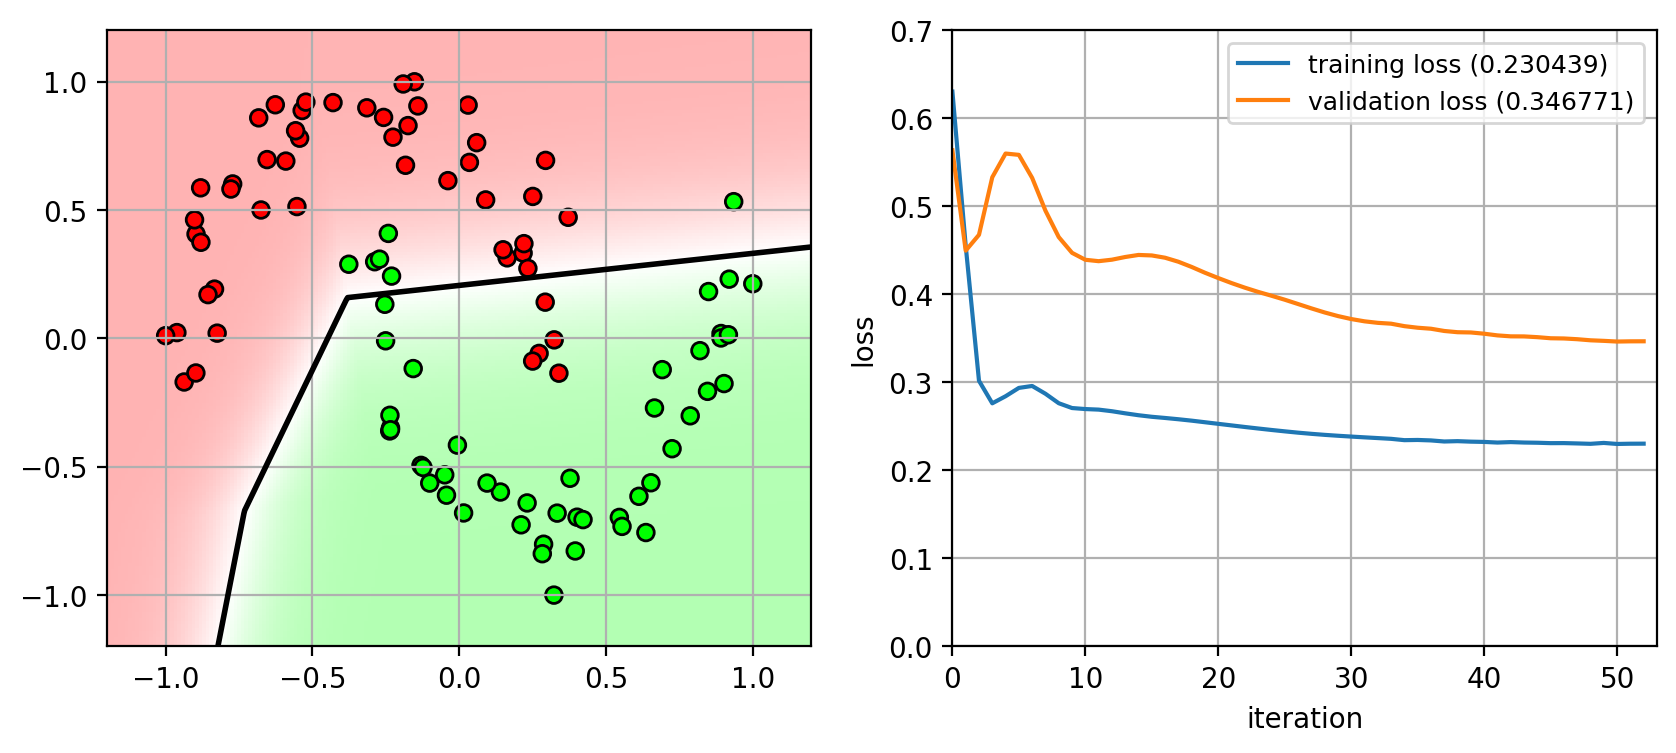

In [19]:
nnfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_nn(model, axbox, X, Y)
plt.subplot(1,2,2)
plot_history(history)
plt.close()

nnfig

- Let's try more nodes
  - 1 hidden layer with 20 hidden nodes

In [20]:
model = MyModel(input_size=2, output_size=2, hidden_sizes=[20])  # MLP model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.3, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(trainX, trainY)  # data loaders
val_loader = get_dataloader(valX, valY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=50)

Epoch 1: Train Loss: 0.6014, Train Acc: 0.6778, Val Loss: 0.4945, Val Acc: 0.7000
Epoch 2: Train Loss: 0.3375, Train Acc: 0.8889, Val Loss: 0.4680, Val Acc: 0.8000
Epoch 3: Train Loss: 0.2777, Train Acc: 0.8889, Val Loss: 0.5161, Val Acc: 0.8000
Epoch 4: Train Loss: 0.2792, Train Acc: 0.9000, Val Loss: 0.5402, Val Acc: 0.8000
Epoch 5: Train Loss: 0.2866, Train Acc: 0.8778, Val Loss: 0.5418, Val Acc: 0.8000
Epoch 6: Train Loss: 0.2877, Train Acc: 0.8667, Val Loss: 0.5130, Val Acc: 0.8000
Epoch 7: Train Loss: 0.2744, Train Acc: 0.8778, Val Loss: 0.4772, Val Acc: 0.8000
Epoch 8: Train Loss: 0.2636, Train Acc: 0.8778, Val Loss: 0.4544, Val Acc: 0.8000
Epoch 9: Train Loss: 0.2595, Train Acc: 0.8889, Val Loss: 0.4366, Val Acc: 0.8000
Epoch 10: Train Loss: 0.2569, Train Acc: 0.8778, Val Loss: 0.4291, Val Acc: 0.8000
Epoch 11: Train Loss: 0.2505, Train Acc: 0.8889, Val Loss: 0.4258, Val Acc: 0.8000
Epoch 12: Train Loss: 0.2425, Train Acc: 0.8889, Val Loss: 0.4277, Val Acc: 0.8000
Epoch 13: Tra

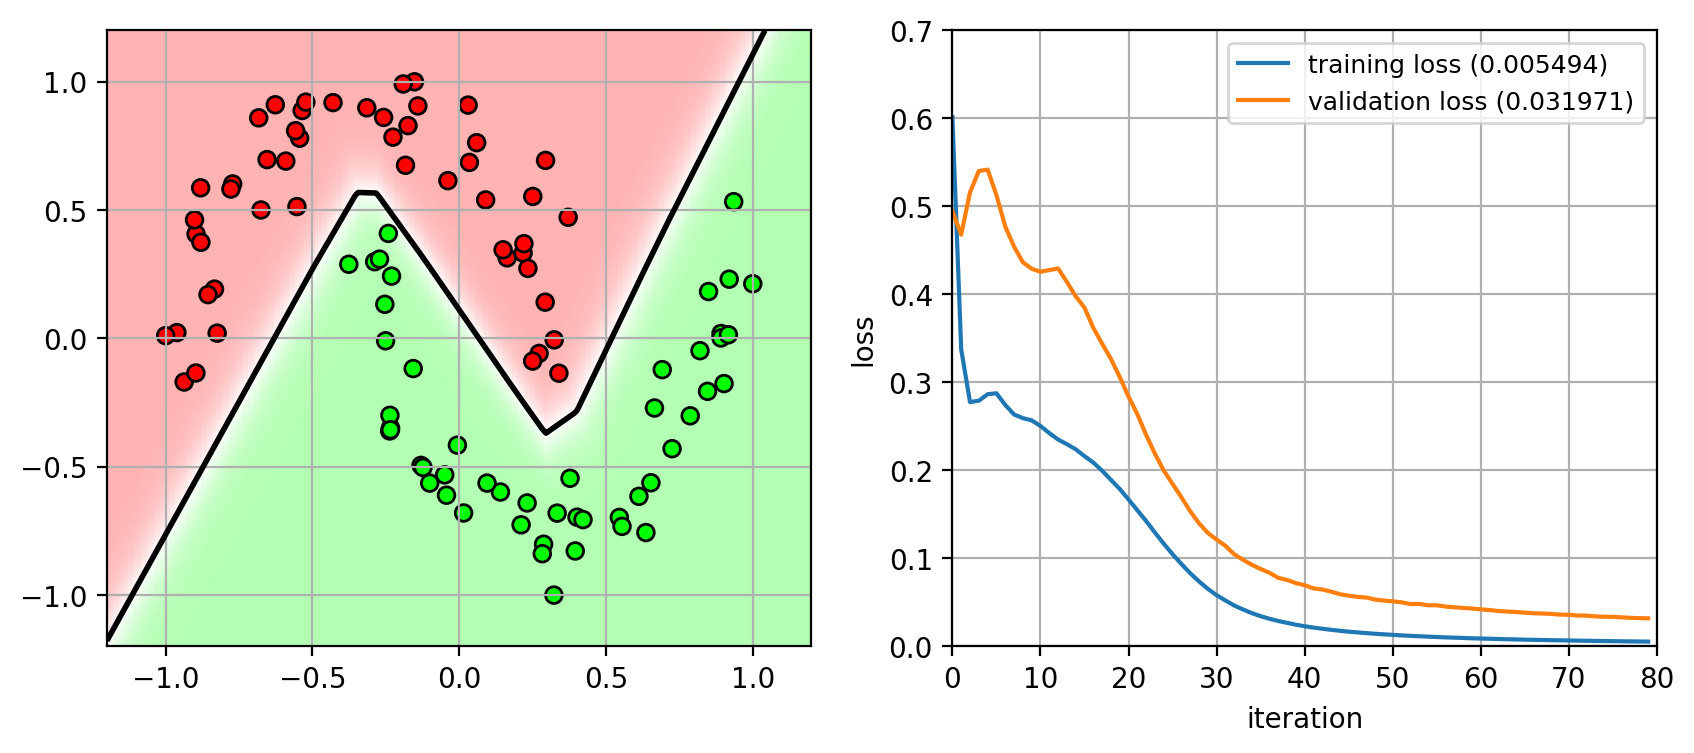

In [21]:
nnfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_nn(model, axbox, X, Y)
plt.subplot(1,2,2)
plot_history(history)
plt.close()

nnfig

# Universal Approximation Theorem
- Cybenko (1989), Hornik (1991)
  - _A multi-layer perceptron with a single hidden layer and a finite number of nodes can approximate any continuous function up to a desired error._
    - The number of nodes needed might be very large.
    - Doesn't say anything about how difficult it is to train it.

- *How many hidden nodes are needed?*
  - In the worst case, consider binary functions mapping $\{0,1\}^n \rightarrow \{0,1\}$
    - there are $2^n$ possible inputs.
    - there are $2^{2^n}$ possible functions (each input has 2 possible outputs)
    - thus, we need $2^n$ bits in the hidden layer to select one of these functions.
  - need $O(2^n)$ nodes in the hidden layer, exponential in the size of the input!


- *How to train this model?*
  - According to the "no free lunch theorem", there is no universally best learning algorithm!

- Deep learning corollary
  - *The number of functions representable by a deep network requires an exponential number of nodes for a shallow network with 1 hidden-layer.*
  - A deep network can learn the same function using less nodes.
  - Given the same number of nodes, a deep network can learn more complex functions.
- Doesn't say anything about how difficult it is to train it.

# Example
- Network with 1 hidden layer
  - input (2D) -> 40 hidden nodes -> output (2D)

In [22]:
trainX2 = vstack((trainX, trainX+array([1.2,0], dtype=np.float32)))
valX2 = vstack((valX, valX+array([1.2,0], dtype=np.float32)))
trainY2 = r_[trainY, trainY]
valY2 = r_[valY, valY]
axbox2 = [-1.2, 2.5, -1.2, 1.2]

In [23]:
model = MyModel(input_size=2, output_size=2, hidden_sizes=[40])  # MLP model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.2, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(trainX2, trainY2)  # data loaders
val_loader = get_dataloader(valX2, valY2)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=50)

Epoch 1: Train Loss: 0.5441, Train Acc: 0.6833, Val Loss: 0.4883, Val Acc: 0.8000
Epoch 2: Train Loss: 0.3665, Train Acc: 0.8500, Val Loss: 0.5378, Val Acc: 0.8000
Epoch 3: Train Loss: 0.3475, Train Acc: 0.8500, Val Loss: 0.5654, Val Acc: 0.7000
Epoch 4: Train Loss: 0.3257, Train Acc: 0.8444, Val Loss: 0.4911, Val Acc: 0.8500
Epoch 5: Train Loss: 0.3034, Train Acc: 0.8556, Val Loss: 0.4588, Val Acc: 0.8000
Epoch 6: Train Loss: 0.3019, Train Acc: 0.8611, Val Loss: 0.4507, Val Acc: 0.8000
Epoch 7: Train Loss: 0.2926, Train Acc: 0.8556, Val Loss: 0.4476, Val Acc: 0.8000
Epoch 8: Train Loss: 0.2890, Train Acc: 0.8500, Val Loss: 0.4448, Val Acc: 0.8500
Epoch 9: Train Loss: 0.2840, Train Acc: 0.8500, Val Loss: 0.4432, Val Acc: 0.8500
Epoch 10: Train Loss: 0.2790, Train Acc: 0.8556, Val Loss: 0.4415, Val Acc: 0.8500
Epoch 11: Train Loss: 0.2750, Train Acc: 0.8667, Val Loss: 0.4326, Val Acc: 0.8000
Epoch 12: Train Loss: 0.2723, Train Acc: 0.8667, Val Loss: 0.4278, Val Acc: 0.8500
Epoch 13: Tra

In [24]:
summary_nn(model)

MyModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=2, bias=True)
  )
)
Param: network.0.weight	Shape: [40, 2]	Numel: 80
Param: network.0.bias	Shape: [40]	Numel: 40
Param: network.2.weight	Shape: [2, 40]	Numel: 80
Param: network.2.bias	Shape: [2]	Numel: 2
Total Numel = 202


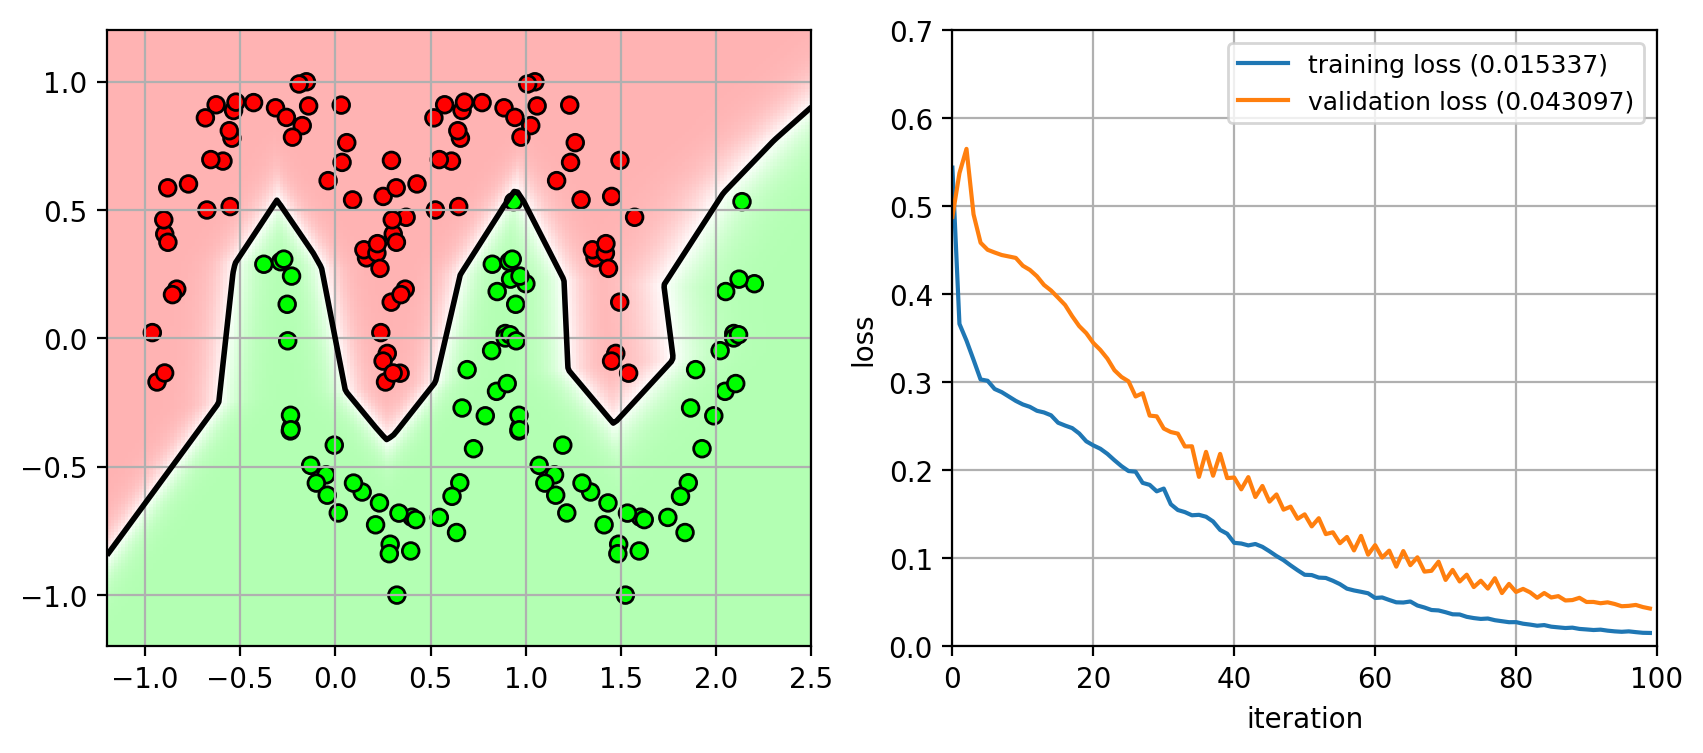

In [25]:
nnfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_nn(model, axbox2, trainX2, trainY2)
plt.subplot(1,2,2)
plot_history(history)
plt.close()

nnfig

- More hidden layers:
  - input (2D) -> 16 nodes -> 16 nodes -> output (2D)

In [26]:
model = MyModel(input_size=2, output_size=2, hidden_sizes=[16, 16])  # MLP model
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(trainX2, trainY2)  # data loaders
val_loader = get_dataloader(valX2, valY2)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=50)

Epoch 1: Train Loss: 0.6153, Train Acc: 0.7389, Val Loss: 0.5550, Val Acc: 0.7000
Epoch 2: Train Loss: 0.3982, Train Acc: 0.8667, Val Loss: 0.4936, Val Acc: 0.8000
Epoch 3: Train Loss: 0.3542, Train Acc: 0.8500, Val Loss: 0.5445, Val Acc: 0.8000
Epoch 4: Train Loss: 0.3557, Train Acc: 0.8611, Val Loss: 0.5140, Val Acc: 0.8500
Epoch 5: Train Loss: 0.3206, Train Acc: 0.8333, Val Loss: 0.4709, Val Acc: 0.8000
Epoch 6: Train Loss: 0.3078, Train Acc: 0.8444, Val Loss: 0.4589, Val Acc: 0.8000
Epoch 7: Train Loss: 0.3065, Train Acc: 0.8611, Val Loss: 0.4617, Val Acc: 0.8000
Epoch 8: Train Loss: 0.3043, Train Acc: 0.8500, Val Loss: 0.4640, Val Acc: 0.8000
Epoch 9: Train Loss: 0.3011, Train Acc: 0.8444, Val Loss: 0.4645, Val Acc: 0.8000
Epoch 10: Train Loss: 0.2975, Train Acc: 0.8389, Val Loss: 0.4613, Val Acc: 0.8500
Epoch 11: Train Loss: 0.2940, Train Acc: 0.8500, Val Loss: 0.4555, Val Acc: 0.8500
Epoch 12: Train Loss: 0.2913, Train Acc: 0.8500, Val Loss: 0.4516, Val Acc: 0.8500
Epoch 13: Tra

In [27]:
summary_nn(model)

MyModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)
Param: network.0.weight	Shape: [16, 2]	Numel: 32
Param: network.0.bias	Shape: [16]	Numel: 16
Param: network.2.weight	Shape: [16, 16]	Numel: 256
Param: network.2.bias	Shape: [16]	Numel: 16
Param: network.4.weight	Shape: [2, 16]	Numel: 32
Param: network.4.bias	Shape: [2]	Numel: 2
Total Numel = 354


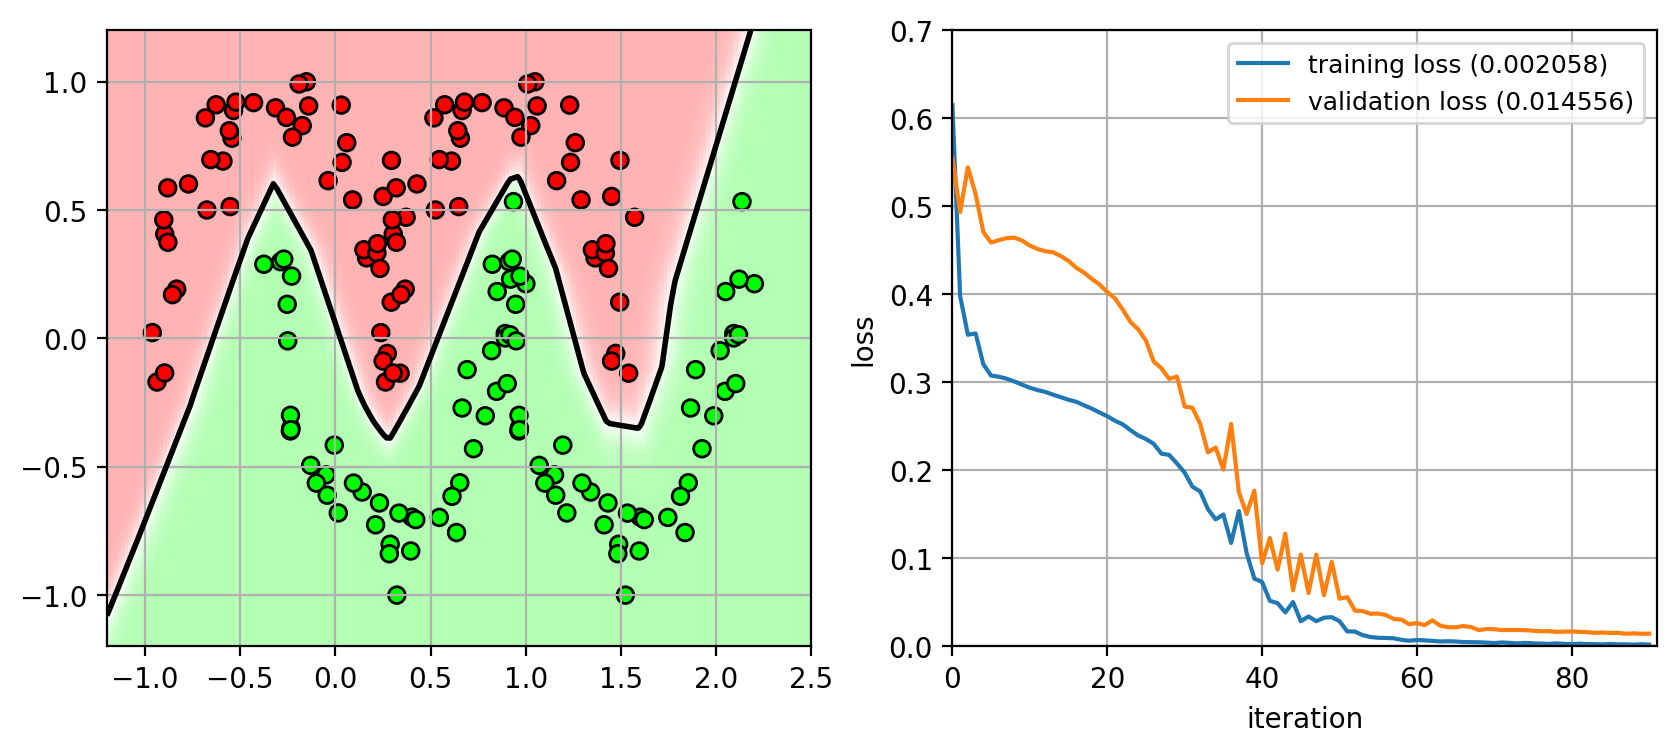

In [28]:
nnfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_nn(model, axbox2, trainX2, trainY2)
plt.subplot(1,2,2)
plot_history(history)
plt.close()

nnfig

# We should use deeper networks...
- Less parameters than a 1 hidden-layer NN 
  - but the number of parameters is still large
- Dataset is still too small.
- *Vanishing Gradient problem*
  - backprop recursively multiplies gradients
     - numerical values get smaller.
     - gradient signal is "washed" out the further back it travels.
- We'll see how to address these problems later.

# Example on MNIST Dataset
- Images are 28x28, digits 0-9
  - 6,000 for training
  - 10,000 for testing

In [29]:
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')  
            if titles is not None:
                plt.title(titles % idx)
            
            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]): 
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')               
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()



In [30]:
import struct

def read_32int(f):
    return struct.unpack('>I', f.read(4))[0]
def read_img(img_path):
    with open(img_path, 'rb') as f:
        magic_num = read_32int(f)
        num_image = read_32int(f)
        n_row = read_32int(f)
        n_col = read_32int(f)
        #print 'num_image = {}; n_row = {}; n_col = {}'.format(num_image, n_row, n_col)
        res = []
        npixel = n_row * n_col
        res_arr = fromfile(f, dtype='B')
        res_arr = res_arr.reshape((num_image, n_row, n_col), order='C')
        #print 'image data shape = {}'.format(res_arr.shape)
        return num_image, n_row, n_col, res_arr    
def read_label(label_path):
    with open(label_path, 'rb') as f:
        magic_num = read_32int(f)
        num_label = read_32int(f)
        #print 'num_label = {}'.format(num_label)
        res_arr = fromfile(f, dtype='B')
        #print res_arr.shape
        #res_arr = res_arr.reshape((num_label, 1))
        res_arr = res_arr.ravel()
        #print 'label data shape = {}'.format(res_arr.shape)
        return num_label, res_arr

In [31]:
n_train, nrow, ncol, trainimg = read_img('data/train-images.idx3-ubyte')
_, trainY = read_label('data/train-labels.idx1-ubyte')
n_test, _, _, testimg = read_img('data/t10k-images.idx3-ubyte')
_, testY = read_label('data/t10k-labels.idx1-ubyte')

# for demonstration we only use 10% of the training data
sample_index = range(0, trainimg.shape[0], 10)
trainimg  = trainimg[sample_index]
trainY    = trainY[sample_index]
print(trainimg.shape)
print(trainY.shape)
print(testimg.shape)
print(testY.shape)

(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


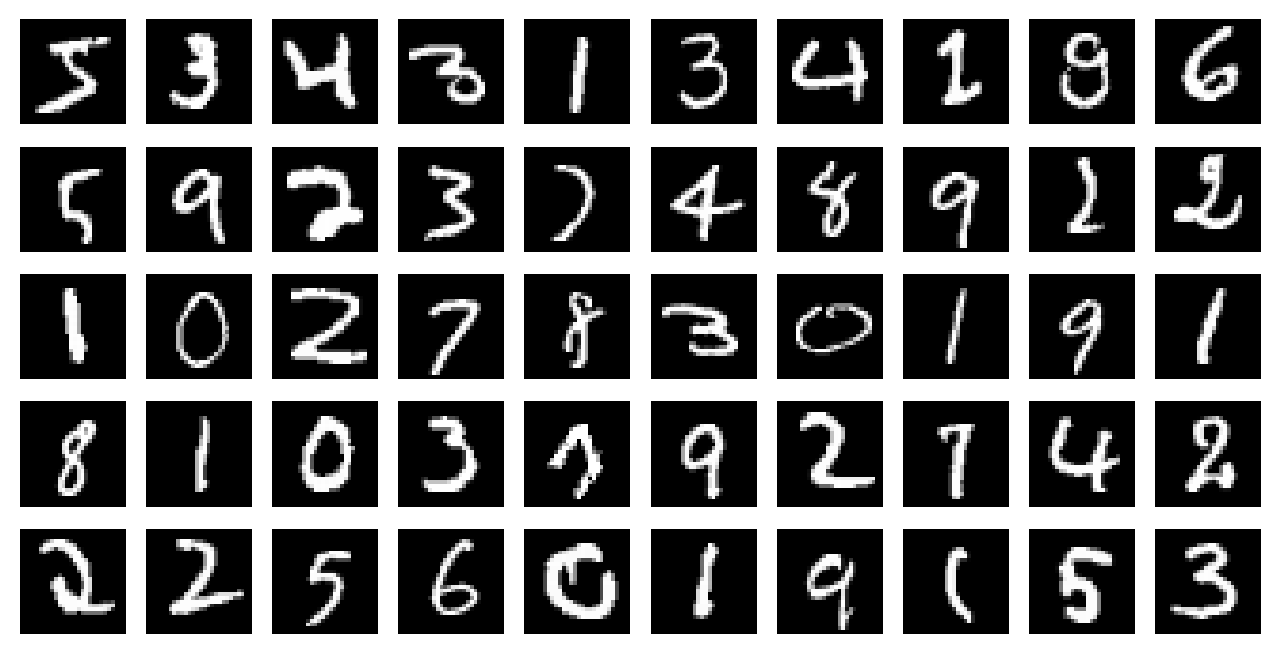

In [32]:
# Example images
plt.figure(figsize=(8,4))
show_imgs(trainimg[0:50])

# Pre-processing
- Reshape images into vectors
- map to [0,1], then subtract the mean

In [33]:
# Reshape the images to a vector
# and map the data to [0,1]
trainXraw = trainimg.reshape((len(trainimg), -1), order='C') / 255.0
testXraw = testimg.reshape((len(testimg), -1), order='C') / 255.0

# center the image data (but don't change variance)
scaler = preprocessing.StandardScaler(with_std=False)
trainX = scaler.fit_transform(trainXraw).astype(np.float32)
testX  = scaler.transform(testXraw).astype(np.float32)

print(trainX.shape)
print(trainY.shape)

(6000, 784)
(6000,)


- Generate a fixed validation set
  - use vtrainX for training and validX for validation

In [34]:
# generate a fixed validation set using 10% of the training set
vtrainX, validX, vtrainY, validY = \
  model_selection.train_test_split(trainX, trainY, 
  train_size=0.9, test_size=0.1, random_state=4487)

# validation data
validset  = (validX, validY)

# MNIST - Logistic Regression (0-hidden layers)
- Training procedure
  - We specify the validation set so that it will be fixed when we change the `random_state` to randomly initialize the weights.
  - Train on the non-validation training data.
  - Use a larger batch size to speed up the algorithm



In [35]:
def plot_history2(history): 
    fig, ax1 = plt.subplots()
    ax1.plot(history['train_loss'], 'r', label="training loss ({:.6f})".format(history['train_loss'][-1]))
    ax1.plot(history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')
    if 'train_acc' in history:
        ax2 = ax1.twinx()
        ax2.plot(history['train_acc'], 'b', label="training acc ({:.4f})".format(history['train_acc'][-1]))
        ax2.plot(history['val_acc'], 'b--', label="validation acc ({:.4f})".format(history['val_acc'][-1]))
        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')

In [36]:
model = MyModel(input_size=784, output_size=10, hidden_sizes=[])
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(vtrainX, vtrainY)  # data loaders
val_loader = get_dataloader(validX, validY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10)

Epoch 1: Train Loss: 0.5367, Train Acc: 0.8357, Val Loss: 0.3920, Val Acc: 0.8867
Epoch 2: Train Loss: 0.3476, Train Acc: 0.9017, Val Loss: 0.3694, Val Acc: 0.8950
Epoch 3: Train Loss: 0.3062, Train Acc: 0.9130, Val Loss: 0.3644, Val Acc: 0.8967
Epoch 4: Train Loss: 0.2801, Train Acc: 0.9207, Val Loss: 0.3647, Val Acc: 0.8950
Epoch 5: Train Loss: 0.2609, Train Acc: 0.9283, Val Loss: 0.3670, Val Acc: 0.8900
Epoch 6: Train Loss: 0.2456, Train Acc: 0.9344, Val Loss: 0.3702, Val Acc: 0.8850
Epoch 7: Train Loss: 0.2328, Train Acc: 0.9372, Val Loss: 0.3738, Val Acc: 0.8833
Epoch 8: Train Loss: 0.2219, Train Acc: 0.9407, Val Loss: 0.3776, Val Acc: 0.8833
Epoch 9: Train Loss: 0.2123, Train Acc: 0.9422, Val Loss: 0.3816, Val Acc: 0.8850
Epoch 10: Train Loss: 0.2038, Train Acc: 0.9439, Val Loss: 0.3856, Val Acc: 0.8850
Epoch 11: Train Loss: 0.1960, Train Acc: 0.9448, Val Loss: 0.3897, Val Acc: 0.8850
Epoch 12: Train Loss: 0.1890, Train Acc: 0.9474, Val Loss: 0.3938, Val Acc: 0.8867
Epoch 13: Tra

MyModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)
Param: network.0.weight	Shape: [10, 784]	Numel: 7840
Param: network.0.bias	Shape: [10]	Numel: 10
Total Numel = 7850
test accuracy: 0.8813


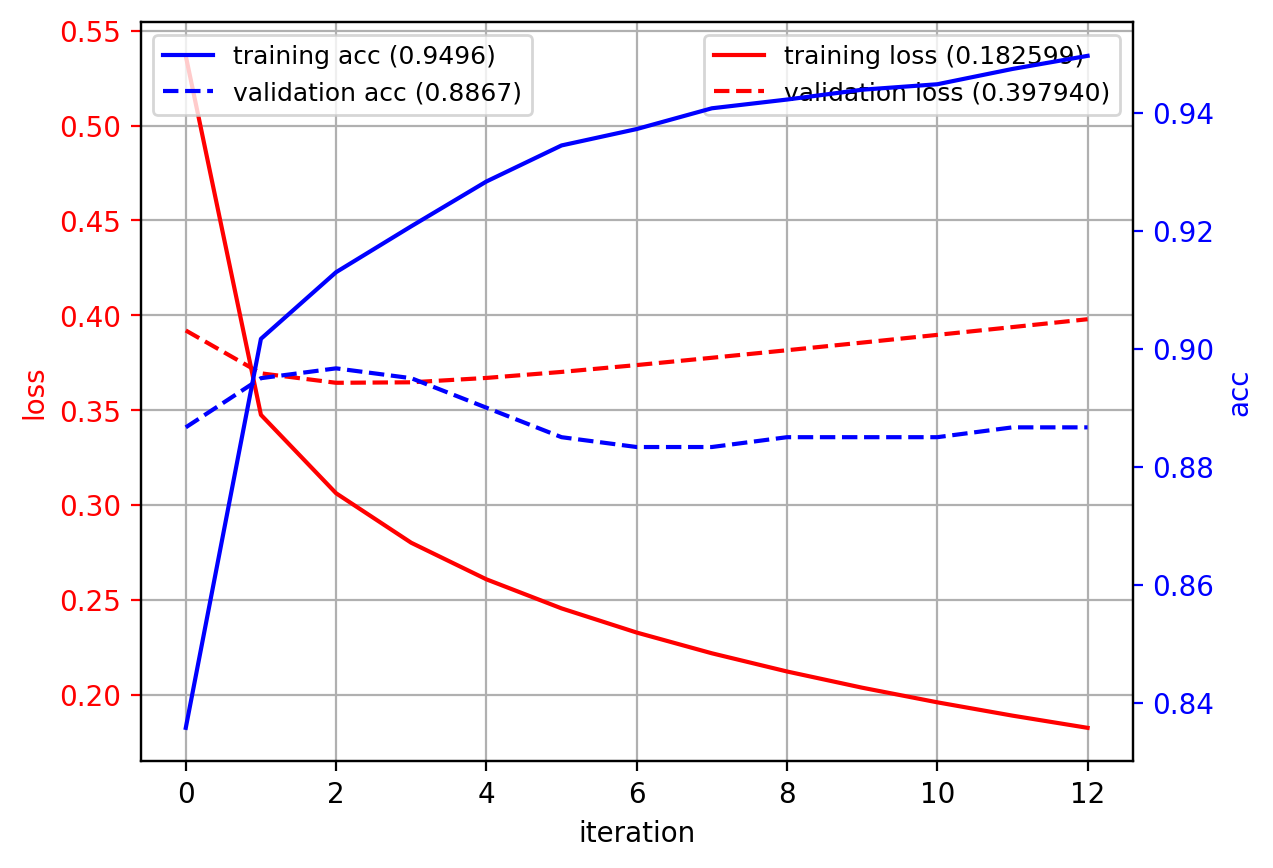

In [37]:
summary_nn(model)
plot_history2(history)

with torch.no_grad():
    predY = model(torch.as_tensor(testX)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

In [38]:
params = model.network[0].weight.data
print(params)

tensor([[ 3.3546e-02, -3.4324e-02,  2.0939e-02,  ..., -2.0905e-02,
          1.1012e-02, -3.1561e-02],
        [ 2.7129e-02,  3.1136e-03, -1.7196e-02,  ..., -1.5344e-02,
         -2.0055e-02, -2.7852e-03],
        [ 2.9864e-02, -3.4973e-02, -1.7804e-02,  ...,  1.1404e-02,
         -8.0777e-03, -5.1047e-05],
        ...,
        [-1.3821e-02, -1.6467e-03, -2.6531e-03,  ...,  2.2454e-02,
          1.5731e-02,  5.1474e-03],
        [-4.0478e-03,  2.0415e-02, -5.3243e-03,  ...,  2.2182e-02,
         -2.7403e-02, -2.7426e-02],
        [-2.7465e-02, -8.7818e-03,  2.0570e-02,  ..., -5.8698e-05,
         -1.5991e-02, -1.2174e-04]])


- Reshape the weights into an image
  - input images that match the weights will have high response for that class.

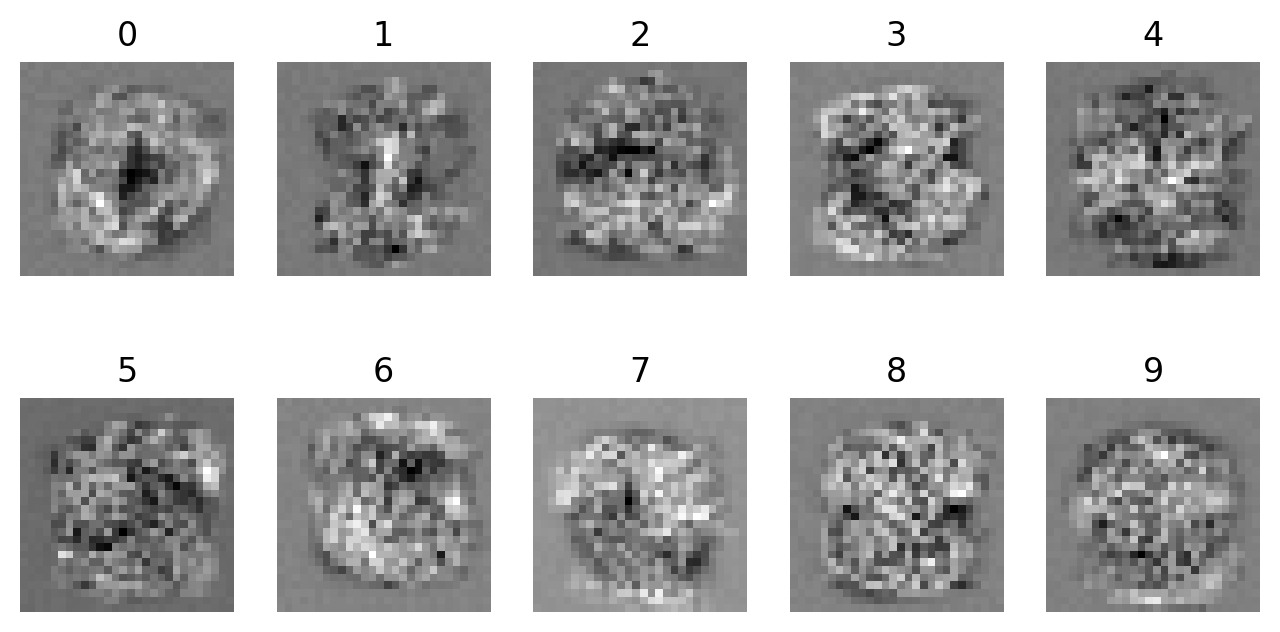

In [39]:
filter_list = [w.view((28,28)) for w in params]
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=5, titles="%d")

# MNIST - 1-hidden layer
- Add 1 hidden layer with 50 ReLu nodes
  - each node is extracting a feature from the input image

Epoch 1: Train Loss: 0.6059, Train Acc: 0.8113, Val Loss: 0.3687, Val Acc: 0.8883
Epoch 2: Train Loss: 0.2468, Train Acc: 0.9230, Val Loss: 0.2699, Val Acc: 0.9150
Epoch 3: Train Loss: 0.1468, Train Acc: 0.9541, Val Loss: 0.2788, Val Acc: 0.9250
Epoch 4: Train Loss: 0.0880, Train Acc: 0.9726, Val Loss: 0.2912, Val Acc: 0.9250
Epoch 5: Train Loss: 0.0652, Train Acc: 0.9763, Val Loss: 0.3335, Val Acc: 0.9300
Epoch 6: Train Loss: 0.0471, Train Acc: 0.9843, Val Loss: 0.3678, Val Acc: 0.9267
Epoch 7: Train Loss: 0.0447, Train Acc: 0.9837, Val Loss: 0.4609, Val Acc: 0.9217
Epoch 8: Train Loss: 0.0420, Train Acc: 0.9867, Val Loss: 0.3310, Val Acc: 0.9417
Epoch 9: Train Loss: 0.0320, Train Acc: 0.9889, Val Loss: 0.4100, Val Acc: 0.9250
Epoch 10: Train Loss: 0.0167, Train Acc: 0.9952, Val Loss: 0.3778, Val Acc: 0.9367
Epoch 11: Train Loss: 0.0118, Train Acc: 0.9965, Val Loss: 0.3964, Val Acc: 0.9283
Epoch 12: Train Loss: 0.0091, Train Acc: 0.9981, Val Loss: 0.3672, Val Acc: 0.9433
Epoch 13: Tra

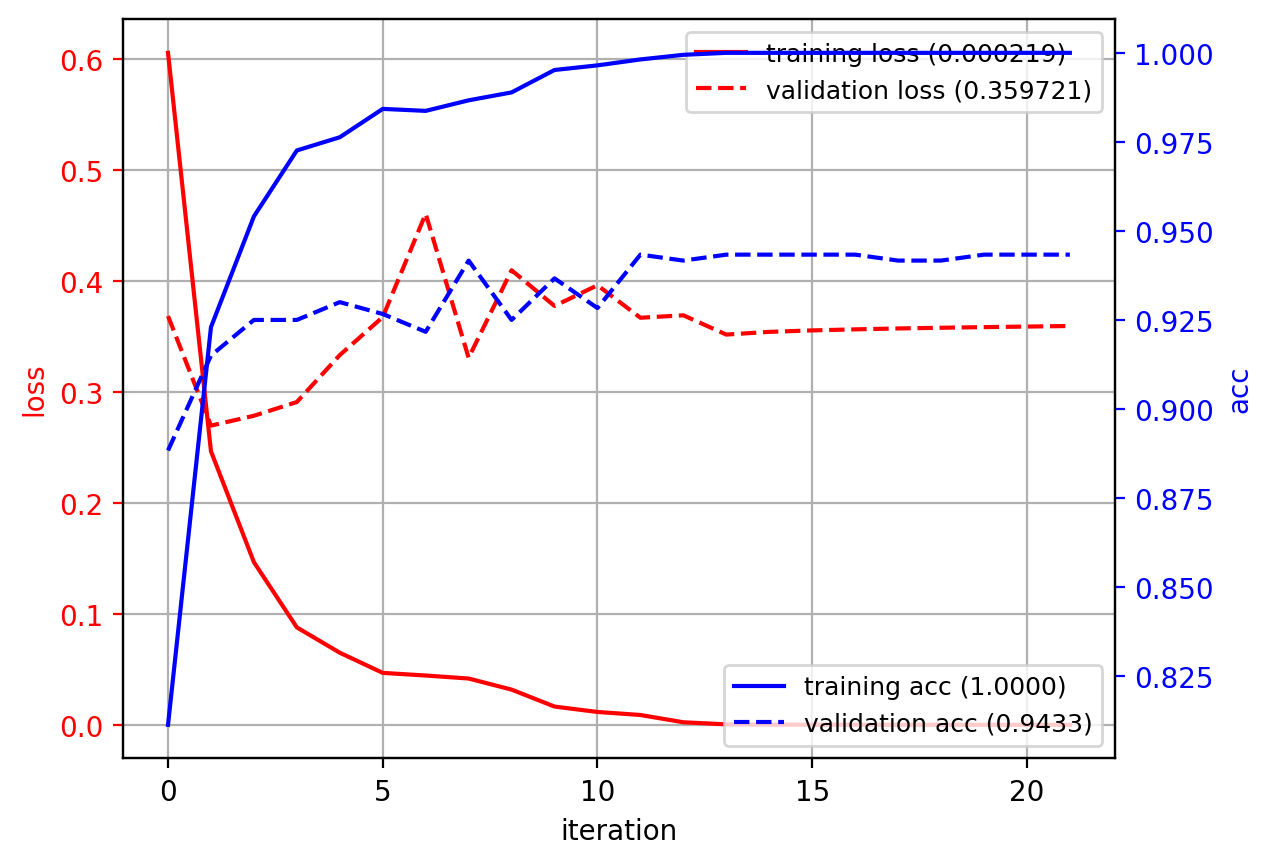

In [40]:
model = MyModel(input_size=784, output_size=10, hidden_sizes=[50])
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(vtrainX, vtrainY)  # data loaders
val_loader = get_dataloader(validX, validY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10)
# summary and plot
summary_nn(model)
plot_history2(history)
# test
with torch.no_grad():
    predY = model(torch.as_tensor(testX)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

- Examine the weights of the hidden layer
  - $h_i = \sigma(\mathbf{w}_i^T \mathbf{x})$
  - each weight vector is a "pattern prototype" that the node will match
- The hidden nodes look for local structures:
  - oriented edges, curves, other local structures

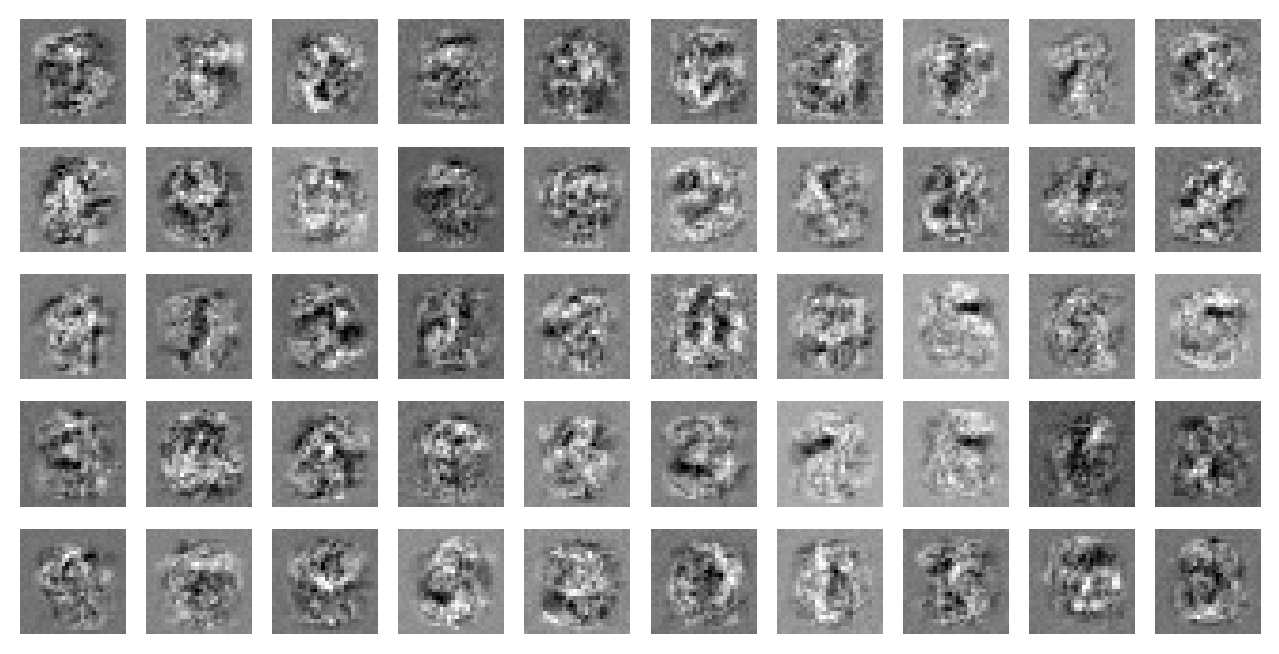

In [41]:
W = model.network[0].weight.data
filter_list = [w.view((28,28)) for w in W]
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=10)

- Examine the weights of the 2nd layer (output)
  - $y_j = \sigma(\mathbf{w}_j^T\mathbf{h})$
  - recall the hidden-layer outputs $h$ are always non-negative.
    - positive value in $\mathbf{w}_j$ $\rightarrow$ class $j$ should have j-th pattern
    - negative value in $\mathbf{w}_j$ $\rightarrow$ class $j$ shouldn't have j-th pattern

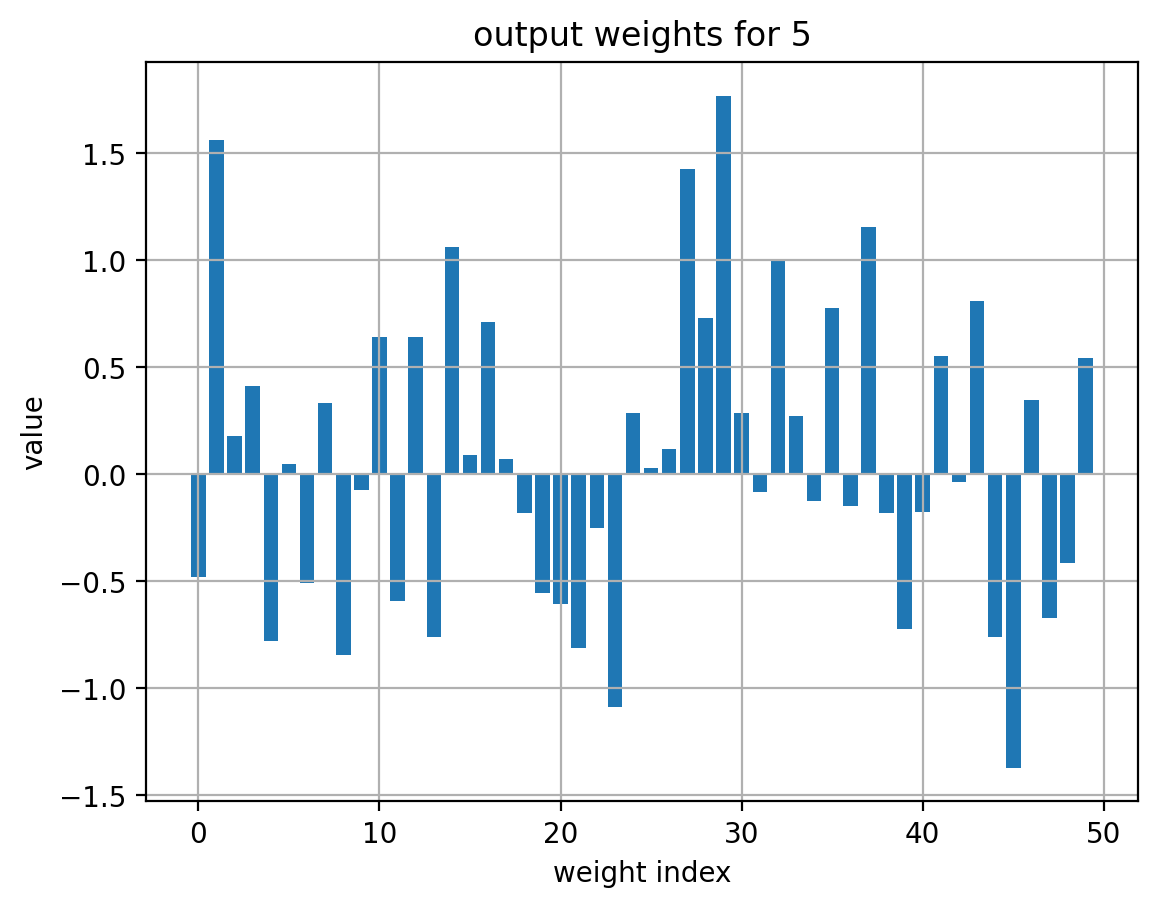

In [42]:
W = model.network[2].weight.data.T  # model.network[1] is the relu
# print(W.shape)
d = 5
plt.bar(arange(0,W.shape[0]),W[:,d]); plt.grid(True);
plt.xlabel('weight index'); plt.ylabel('value')
plt.title('output weights for {}'.format(d));

- For "5", finds local image parts that correspond to 5
  - should have (green boxes):
    - horizontal line at top; semicircle on the bottom
  - shouldn't have (red boxes):
    - vertical line in top-right; verticle line in the middle

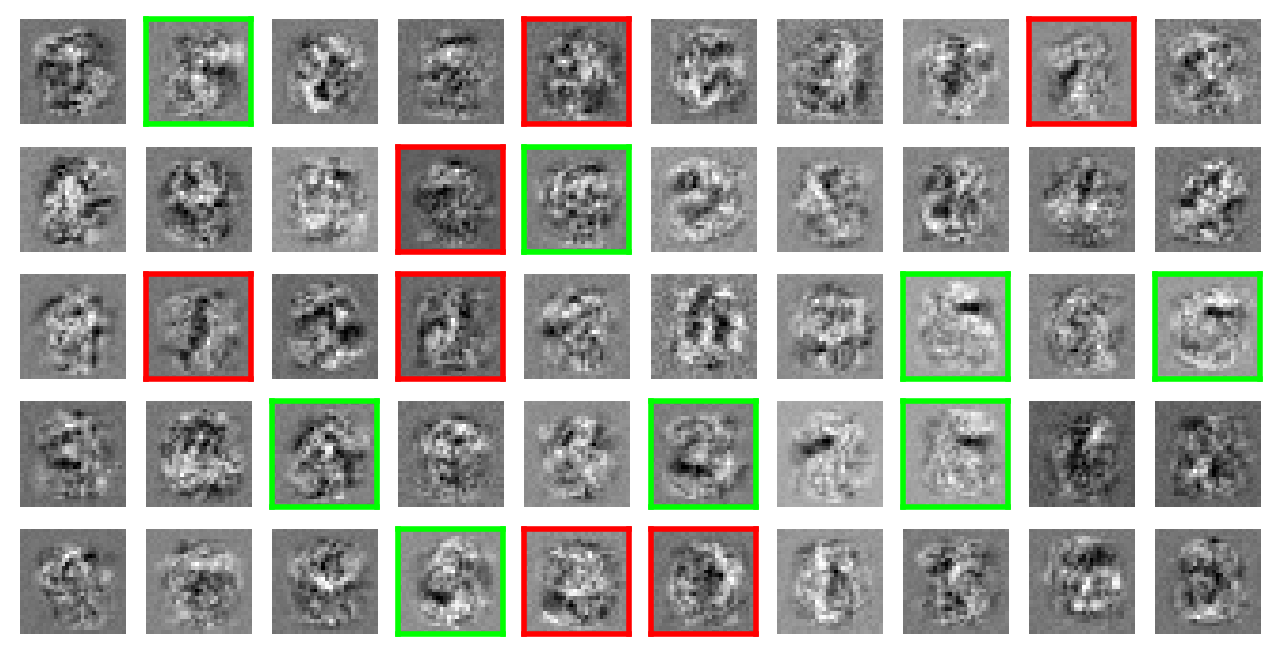

In [43]:
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=10,
          highlight_green=(W[:,d]>0.75), # positive weights are green
          highlight_red=(W[:,d]<-0.75))  # negative weights are red

# 1 Hidden layer with more nodes
- hidden layer with 200 nodes

Epoch 1: Train Loss: 0.5805, Train Acc: 0.8207, Val Loss: 0.3409, Val Acc: 0.8933
Epoch 2: Train Loss: 0.2112, Train Acc: 0.9363, Val Loss: 0.2192, Val Acc: 0.9217
Epoch 3: Train Loss: 0.1060, Train Acc: 0.9657, Val Loss: 0.1864, Val Acc: 0.9433
Epoch 4: Train Loss: 0.0482, Train Acc: 0.9869, Val Loss: 0.2219, Val Acc: 0.9350
Epoch 5: Train Loss: 0.0268, Train Acc: 0.9924, Val Loss: 0.1986, Val Acc: 0.9433
Epoch 6: Train Loss: 0.0142, Train Acc: 0.9967, Val Loss: 0.1868, Val Acc: 0.9500
Epoch 7: Train Loss: 0.0040, Train Acc: 0.9996, Val Loss: 0.1834, Val Acc: 0.9533
Epoch 8: Train Loss: 0.0020, Train Acc: 1.0000, Val Loss: 0.1814, Val Acc: 0.9567
Epoch 9: Train Loss: 0.0014, Train Acc: 1.0000, Val Loss: 0.1819, Val Acc: 0.9567
Epoch 10: Train Loss: 0.0012, Train Acc: 1.0000, Val Loss: 0.1827, Val Acc: 0.9567
Epoch 11: Train Loss: 0.0010, Train Acc: 1.0000, Val Loss: 0.1836, Val Acc: 0.9567
Epoch 12: Train Loss: 0.0009, Train Acc: 1.0000, Val Loss: 0.1845, Val Acc: 0.9567
Epoch 13: Tra

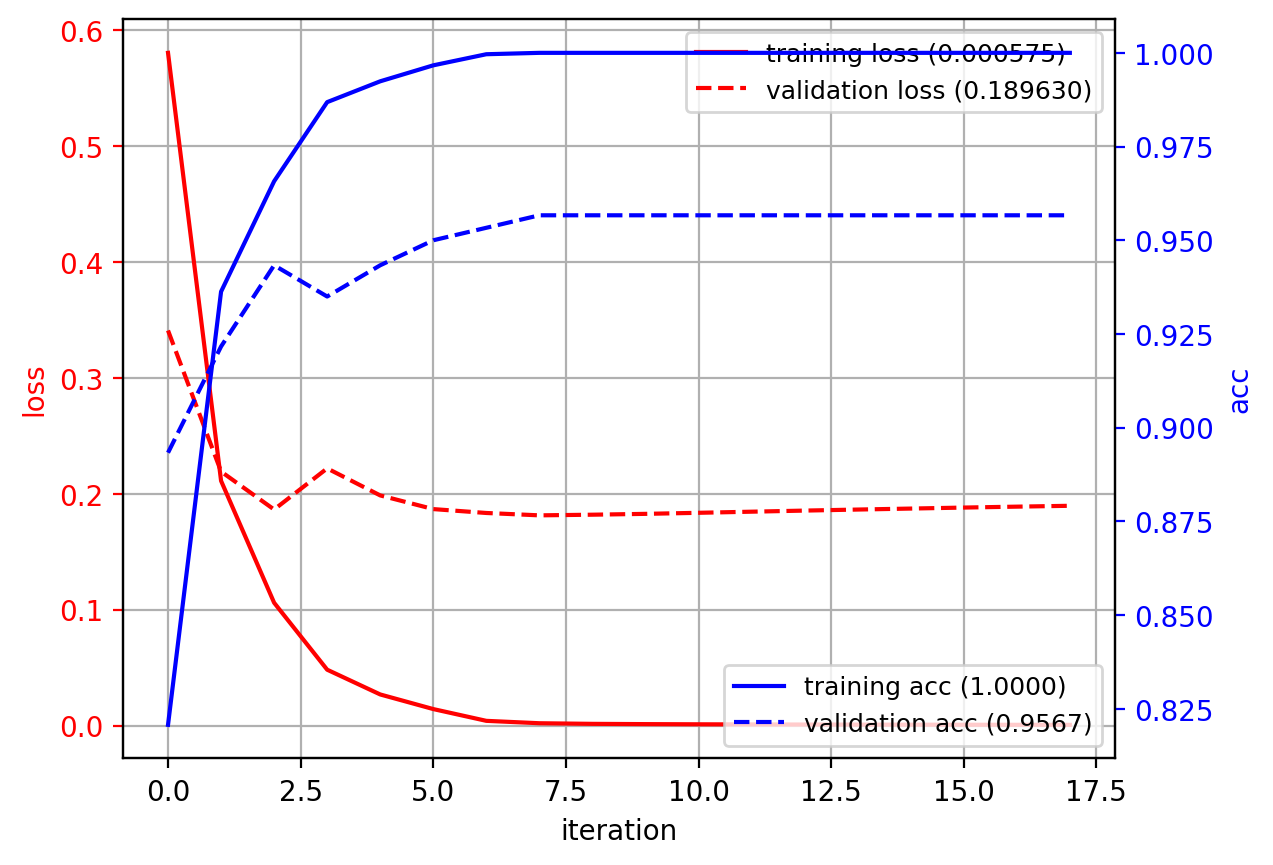

In [44]:
model = MyModel(input_size=784, output_size=10, hidden_sizes=[200])
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(vtrainX, vtrainY)  # data loaders
val_loader = get_dataloader(validX, validY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10)
# summary and plot
summary_nn(model)
plot_history2(history)
# test
with torch.no_grad():
    predY = model(torch.as_tensor(testX)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

- hidden layer with 1000 nodes

Epoch 1: Train Loss: 0.5448, Train Acc: 0.8306, Val Loss: 0.3040, Val Acc: 0.9033
Epoch 2: Train Loss: 0.1883, Train Acc: 0.9413, Val Loss: 0.1980, Val Acc: 0.9333
Epoch 3: Train Loss: 0.0748, Train Acc: 0.9774, Val Loss: 0.1955, Val Acc: 0.9367
Epoch 4: Train Loss: 0.0360, Train Acc: 0.9907, Val Loss: 0.2168, Val Acc: 0.9383
Epoch 5: Train Loss: 0.0151, Train Acc: 0.9963, Val Loss: 0.1990, Val Acc: 0.9467
Epoch 6: Train Loss: 0.0078, Train Acc: 0.9983, Val Loss: 0.1726, Val Acc: 0.9567
Epoch 7: Train Loss: 0.0026, Train Acc: 1.0000, Val Loss: 0.1787, Val Acc: 0.9500
Epoch 8: Train Loss: 0.0016, Train Acc: 1.0000, Val Loss: 0.1758, Val Acc: 0.9517
Epoch 9: Train Loss: 0.0013, Train Acc: 1.0000, Val Loss: 0.1766, Val Acc: 0.9500
Epoch 10: Train Loss: 0.0011, Train Acc: 1.0000, Val Loss: 0.1779, Val Acc: 0.9533
Epoch 11: Train Loss: 0.0010, Train Acc: 1.0000, Val Loss: 0.1792, Val Acc: 0.9533
Epoch 12: Train Loss: 0.0009, Train Acc: 1.0000, Val Loss: 0.1804, Val Acc: 0.9533
Epoch 13: Tra

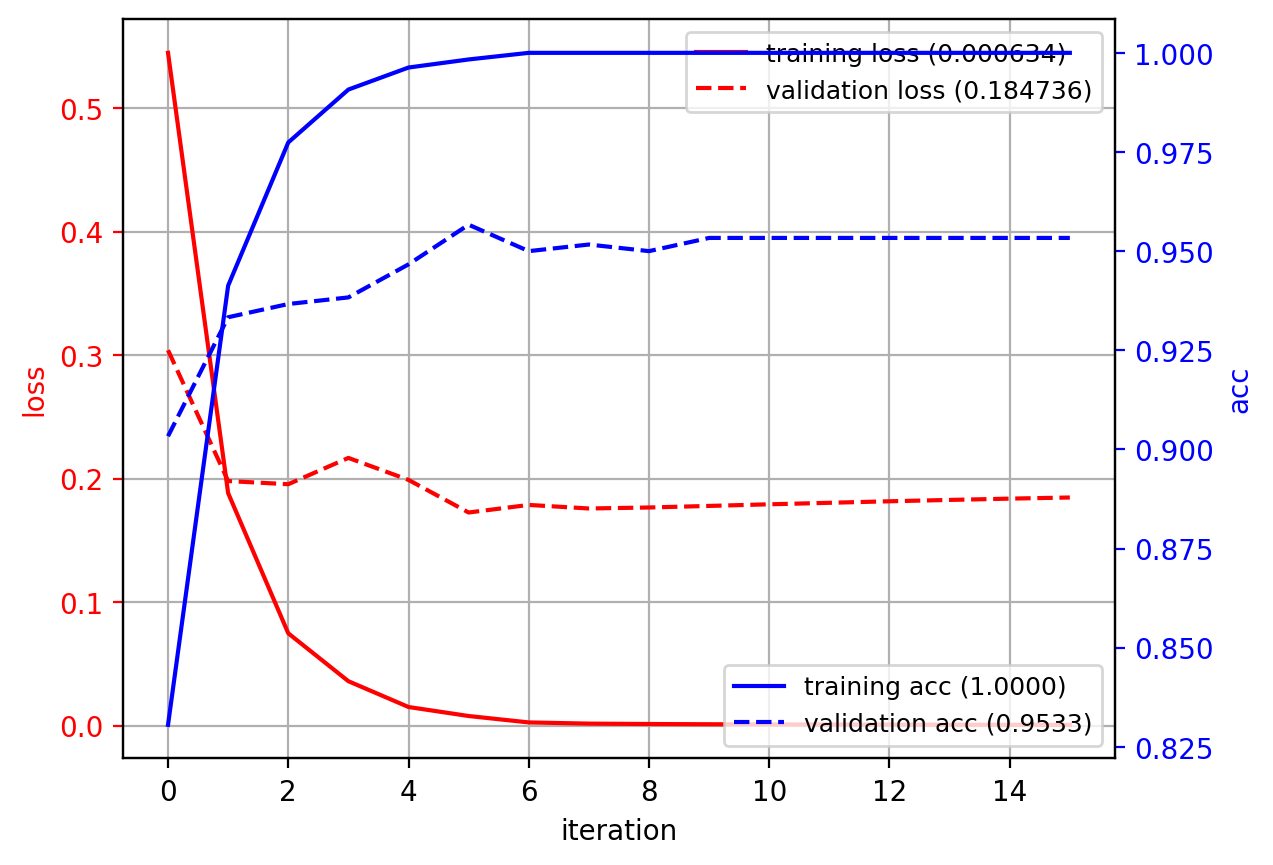

In [45]:
model = MyModel(input_size=784, output_size=10, hidden_sizes=[1000])
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # optimizer
train_loader = get_dataloader(vtrainX, vtrainY)  # data loaders
val_loader = get_dataloader(validX, validY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10)
# summary and plot
summary_nn(model)
plot_history2(history)
# test
with torch.no_grad():
    predY = model(torch.as_tensor(testX)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

- 2 hidden layers
  - input (28x28) -> 500 nodes -> 500 nodes -> output
  - Slightly better

Epoch 1: Train Loss: 0.7761, Train Acc: 0.7593, Val Loss: 0.3708, Val Acc: 0.8883
Epoch 2: Train Loss: 0.2343, Train Acc: 0.9293, Val Loss: 0.2346, Val Acc: 0.9167
Epoch 3: Train Loss: 0.1207, Train Acc: 0.9644, Val Loss: 0.1822, Val Acc: 0.9367
Epoch 4: Train Loss: 0.0652, Train Acc: 0.9811, Val Loss: 0.2022, Val Acc: 0.9367
Epoch 5: Train Loss: 0.0323, Train Acc: 0.9902, Val Loss: 0.2170, Val Acc: 0.9350
Epoch 6: Train Loss: 0.0358, Train Acc: 0.9876, Val Loss: 0.2501, Val Acc: 0.9317
Epoch 7: Train Loss: 0.0205, Train Acc: 0.9937, Val Loss: 0.2440, Val Acc: 0.9467
Epoch 8: Train Loss: 0.0073, Train Acc: 0.9980, Val Loss: 0.2113, Val Acc: 0.9467
Epoch 9: Train Loss: 0.0048, Train Acc: 0.9989, Val Loss: 0.2141, Val Acc: 0.9467
Epoch 10: Train Loss: 0.0031, Train Acc: 0.9993, Val Loss: 0.2185, Val Acc: 0.9467
Epoch 11: Train Loss: 0.0008, Train Acc: 1.0000, Val Loss: 0.2110, Val Acc: 0.9500
Epoch 12: Train Loss: 0.0004, Train Acc: 1.0000, Val Loss: 0.2112, Val Acc: 0.9533
Epoch 13: Tra

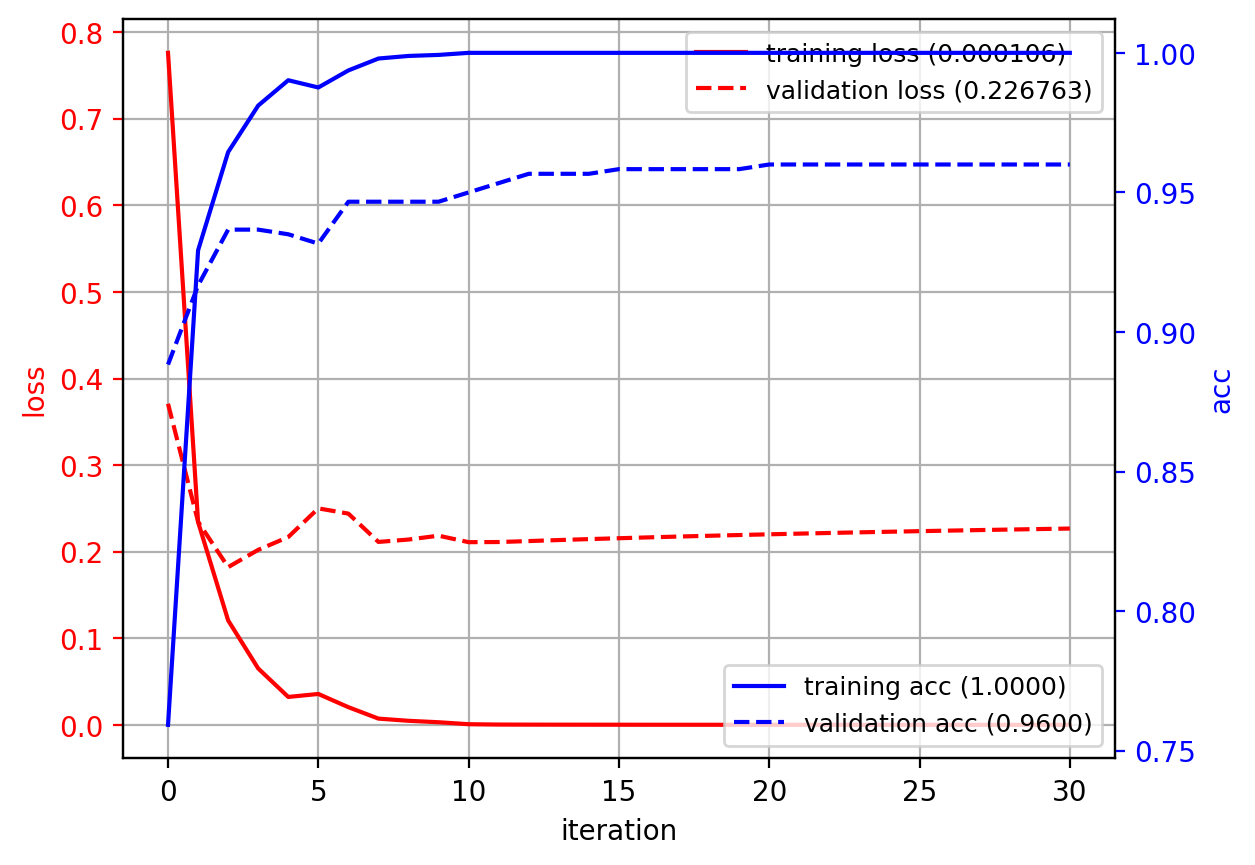

In [46]:
model = MyModel(input_size=784, output_size=10, hidden_sizes=[500, 500])
criterion = nn.CrossEntropyLoss()  # loss function
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, nesterov=True)  # note: need to tune the learning rate!
train_loader = get_dataloader(vtrainX, vtrainY)  # data loaders
val_loader = get_dataloader(validX, validY)
# train the model
history = train_model(model, criterion, train_loader, val_loader, total_epoch=100, patience=10)
# summary and plot
summary_nn(model)
plot_history2(history)
# test
with torch.no_grad():
    predY = model(torch.as_tensor(testX)).argmax(-1)
acc = metrics.accuracy_score(testY, predY)
print("test accuracy:", acc)

# Comparison on MNIST
- Performance is saturated.
<center><table style="font-size:10pt;">
<tr>
  <th>Type</th>
  <th>No.Layers</th>
  <th>Architecture</th>
  <th>No.Parameters</th>
  <th>Test Accuracy</th>
</tr><tr>
  <td>LR</td>
  <td>1</td>
  <td>output(10)</td>
  <td>7,850</td>
  <td>0.8813</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>ReLu(50), output(10)</td>
  <td>39,760</td>
  <td>0.9395</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>Relu(200), output(10)</td>
  <td>159,010</td>
  <td>0.9464</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>Relu(1000), output(10)</td>
  <td>795,010</td>
  <td>0.9482</td>
</tr><tr>
  <td>MLP</td>
  <td>3</td>
  <td>ReLu(500), Relu(500), output(10)</td>
  <td>648,010</td>
  <td>0.9463</td>
</tr>
</table></center>

# Summary
- **Different types of neural networks**
  - _Perceptron_ - single node (similar to logistic regression)
  - _Multi-layer perceptron (MLP)_ - collection of perceptrons in layers
    - also called _fully-connected layers_ or _dense layers_
- **Training**
  - optimize loss function using stochastic gradient descent

- **Advantages**
  - lots of parameters - large capacity to learn from large amounts of data
- **Disadvantages**
  - lots of parameters - easy to overfit data
    - need to monitor the training process
  - sensitive to initialization, learning rate, training algorithm.

# Other things
- **Numerical stability**
  - normalize the inputs to [-1,1] or [0,1]
- **Improving speed**
  - parallelize computations using GPU (Nvidia+CUDA)
- **Initialization**
  - the resulting network is still sensitive to initialization.
    - Solution: train several networks and combine them as an ensemble.
- **Training problems**
  - For very deep networks, the "vanishing gradient" problem can hinder convergence
  - lack of data
  - We will see how to address these problems later.

# References
- Software
  - pytorch: https://pytorch.org/
  - see Canvas site for installation tips.
- History:
  - https://en.wikipedia.org/wiki/History_of_artificial_neural_networks
- Online courses:
  - http://cs231n.github.io/neural-networks-1/
  - http://cs231n.github.io/convolutional-networks/